# Практическая работа 2. Парсинг HTML и консолидация данных

**Студент:** *Давидченко Елена Евгеньевна*

**Вариант:** №6

**Бизнес-кейс:**  Анализ отзывов на товары: проанализировать отзывы на 2-3 популярные модели смартфонов на otzovik.com и выявить топ-5 самых частых проблем и преимуществ

**Источник:** Отзывы на 2-3 популярные модели смартфонов на otzovik.com

**Задача:** Собрать тексты отзывов, оценки, достоинства и недостатки. Выявить топ-5 самых частых проблем и
преимуществ

## Цель работы

Получение знаний о продвинутой технике сбора данных, используя парсинг html-страниц с сайта otzovik.com,и их дальнейшая консолидации и проведения аналитического исследования для выявления топ 5 частых проблем и преимущест моделей телфона.

## Теоретическая часть

**Парсинг HTML** — это процесс автоматизированного извлечения данных из веб-страниц. Веб-страницы написаны на языке гипертекстовой разметки (HTML), который имеет древовидную структуру. Парсеры анализируют эту структуру для навигации по ней и извлечения нужной информации (текста, ссылок, атрибутов).

**Ключевые библиотеки:**
- **`requests`**: позволяет отправлять HTTP-запросы к веб-серверу и получать в ответ HTML-код страницы. Это первый шаг любого парсинга — получение исходного кода.
- **`BeautifulSoup`**: создает из полученного HTML-кода объектное представление (дерево объектов), по которому можно легко перемещаться и искать нужные элементы с помощью тегов, классов, идентификаторов и других атрибутов. Это основной инструмент для извлечения данных из HTML.

### Шаг 1. Установка необходимых библиотек

In [ ]:
!pip install -q requests beautifulsoup4 pandas matplotlib seaborn

Шаг 2. написание парсера для отзывов и оценок моделей телефона

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

# модели смартфонов 
URLS = {
    "iPhone 17 Pro Max": "https://otzovik.com/reviews/smartphone_apple_iphone_17_pro_max/",
    "iPhone 17 Air": "https://otzovik.com/reviews/smartphone_apple_iphone_17_air/",
    "iPhone 17": "https://otzovik.com/reviews/smartphone_apple_iphone_17/"
}

PAGES = 5  # сколько страниц парсить
all_reviews = []


def parse_review_block(block):
    """Парсинг одного блока отзыва"""

    #  рейтинг
    rating_block = block.find("div", class_="rating-score")
    rating = rating_block.find("span").text.strip() if rating_block else None

    # описание
    teaser_block = block.find("div", class_="review-teaser")
    teaser = teaser_block.text.strip() if teaser_block else None

    # достоинства
    pros_block = block.find("div", class_="review-plus")
    pros = pros_block.text.replace("Достоинства:", "").strip() if pros_block else None

    # недостатки
    cons_block = block.find("div", class_="review-minus")
    cons = cons_block.text.replace("Недостатки:", "").strip() if cons_block else None

    return rating, teaser, pros, cons




for model_name, base_url in URLS.items():

    print(f"\nПарсим: {model_name}")

    for page in range(1, PAGES + 1):

        url = f"{base_url}?page={page}"
        print(f" → Страница: {url}")

        try:
            response = requests.get(url, headers=HEADERS, timeout=10)
            response.raise_for_status()

        except Exception as e:
            print("Ошибка:", e)
            break

        soup = BeautifulSoup(response.text, "html.parser")

        # все отзывы на странице
        blocks = soup.find_all("div", class_="item", attrs={"itemprop": "review"})
        if not blocks:
            print("Отзывы не найдены на странице.")
            break

        for block in blocks:
            rating, teaser, pros, cons = parse_review_block(block)

            all_reviews.append({
                "model": model_name,
                "rating": rating,
                "teaser": teaser,
                "pros": pros,
                "cons": cons
            })

        time.sleep(3)









=== НАЧИНАЕМ ПАРСИНГ ===


Парсим: iPhone 17 Pro Max
 → Страница: https://otzovik.com/reviews/smartphone_apple_iphone_17_pro_max/?page=1
Ошибка: 507 Server Error: Service Temporarily unavailable... for url: https://otzovik.com/reviews/smartphone_apple_iphone_17_pro_max/?page=1

Парсим: iPhone 17 Air
 → Страница: https://otzovik.com/reviews/smartphone_apple_iphone_17_air/?page=1
Ошибка: 507 Server Error: Service Temporarily unavailable... for url: https://otzovik.com/reviews/smartphone_apple_iphone_17_air/?page=1

Парсим: iPhone 17
 → Страница: https://otzovik.com/reviews/smartphone_apple_iphone_17/?page=1
Ошибка: 507 Server Error: Service Temporarily unavailable... for url: https://otzovik.com/reviews/smartphone_apple_iphone_17/?page=1


In [ ]:
df

,model,rating,teaser,pros,cons
0,iPhone 17 Pro Max,5,"Приветствую, друзья и гости Отзовика! Мне нрав...",Красивый и удобный корпус. Качество фото и видео.,Для меня нет.
1,iPhone 17 Pro Max,5,"Доброго времени суток, дорогие читатели моего ...","Красивый цвет, батарейка , хорошо работает, не...",Не искала
2,iPhone 17 Pro Max,5,Последнее время я хочу себе купить iPhone. Дол...,качество съемки,цена
3,iPhone 17 Pro Max,5,После недели активного использования iPhone 17...,"Идеальный экран, мощная камера, отличная автон...","Дорогой, тяжёлый, легко поцарапать, быстро гре..."
4,iPhone 17 Pro Max,5,"Это мой 4 айфон, как быстро летит время, начал...","Еще мощнее и быстрее предшественника, камера о...",Нет
...,...,...,...,...,...
127,iPhone 17,4,"Телефон сильно не отличается от айфон 16, плюс...","Красивый внешний вид , выглядит дорого",В том что не сильно отличается от 16
128,iPhone 17,5,Мой опыт владения iPhone 17 Решилась наконец-т...,"Дизайн, производительность, отличная камера, у...","Цена высокая, отсутствие быстрой зарядки в ком..."
129,iPhone 17,5,"Пользуюсь уже месяц, словами не передать какое...","Приятный на ощупь это первое ощущение, камера ...",Разве что корпус аллюминиевый который спустя в...
130,iPhone 17,2,"Перешел на iPhone 17 с тринадцатой модели, но ...",Мощный процессор. Качественные фото на основну...,Слабая батарея. Шумы и пересветы в сложных усл...


### Шаг 3. Очистка и преобразование данных об отзывах

добавляем слова исключения, которые часто встречаются и не несут никакой информации

Перебираем имена моделей, отбирает строки df, где колонка "model" равна текущей модели, чтобы получить таблицу только по одной модели.

собираем весь текст достоинст и недостатков, удаляем пустые значения
склеиваем все строки в один текст и приводим к нижнему регистру

извлекаем слова используя регулярку, которая ищет все русские слова

и подсчитываем количество строк

In [ ]:
df

,model,rating,teaser,pros,cons,score
0,iPhone 17 Pro Max,5,"Приветствую, друзья и гости Отзовика! Мне нрав...",Красивый и удобный корпус. Качество фото и видео.,Для меня нет.,5
1,iPhone 17 Pro Max,5,"Доброго времени суток, дорогие читатели моего ...","Красивый цвет, батарейка , хорошо работает, не...",Не искала,5
2,iPhone 17 Pro Max,5,Последнее время я хочу себе купить iPhone. Дол...,качество съемки,цена,5
3,iPhone 17 Pro Max,5,После недели активного использования iPhone 17...,"Идеальный экран, мощная камера, отличная автон...","Дорогой, тяжёлый, легко поцарапать, быстро гре...",5
4,iPhone 17 Pro Max,5,"Это мой 4 айфон, как быстро летит время, начал...","Еще мощнее и быстрее предшественника, камера о...",Нет,5
...,...,...,...,...,...,...
127,iPhone 17,4,"Телефон сильно не отличается от айфон 16, плюс...","Красивый внешний вид , выглядит дорого",В том что не сильно отличается от 16,4
128,iPhone 17,5,Мой опыт владения iPhone 17 Решилась наконец-т...,"Дизайн, производительность, отличная камера, у...","Цена высокая, отсутствие быстрой зарядки в ком...",5
129,iPhone 17,5,"Пользуюсь уже месяц, словами не передать какое...","Приятный на ощупь это первое ощущение, камера ...",Разве что корпус аллюминиевый который спустя в...,5
130,iPhone 17,2,"Перешел на iPhone 17 с тринадцатой модели, но ...",Мощный процессор. Качественные фото на основну...,Слабая батарея. Шумы и пересветы в сложных усл...,2


In [ ]:

# добавляем слова исключения , которые часто встречаются и не несут никакой инфомарции
stop_words = {"не","нет", "и", "в", "на", "хорошая", "нету", "от", "но","очень","высокая","минусов","быстро","для","за","день","непривычно","что","еще","стал"}

for model_name in URLS.keys():
    model_df = df[df["model"] == model_name]
    print(f"\n название телефона: {model_name}")

    # собираем текст
    plus_text = " ".join(model_df["pros"].dropna()).lower()
    minus_text = " ".join(model_df["cons"].dropna()).lower()

    # извлекаем слова
    plus_words = re.findall(r"[а-яa-zё]+", plus_text)
    minus_words = re.findall(r"[а-яa-zё]+", minus_text)

    # фильтруем стоп-слова
    plus_words = [w for w in plus_words if w not in stop_words]
    minus_words = [w for w in minus_words if w not in stop_words]


    plus = pd.Series(plus_words).value_counts().head(5)
    minus = pd.Series(minus_words).value_counts().head(5)


    print("\n Топ-5 преимуществ:")
    print(plus)
    print("\n Топ-5 достоинств:")
    print(minus)



 название телефона: iPhone 17 Pro Max

 Топ-5 преимуществ:
камера                19
дизайн                11
экран                 10
производительность     7
яркий                  6
Name: count, dtype: int64

 Топ-5 достоинств:
цена          17
тяжёлый        4
корпус         4
дорогой        3
царапается     3
Name: count, dtype: int64

 название телефона: iPhone 17 Air

 Топ-5 преимуществ:
легкий                8
тонкий                8
экран                 7
дизайн                5
производительность    5
Name: count, dtype: int64

 Топ-5 достоинств:
цена             5
камера           3
батарея          3
использовании    2
заряда           2
Name: count, dtype: int64

 название телефона: iPhone 17

 Топ-5 преимуществ:
камера     18
экран       6
мощный      4
дизайн      4
батарея     4
Name: count, dtype: int64

 Топ-5 достоинств:
цена            10
комплекте        3
корпус           3
динамиков        2
расположение     2
Name: count, dtype: int64


In [ ]:
df.dtypes

,0
model,object
rating,object
teaser,object
pros,object
cons,object
score,int64


### Шаг 4: Анализ и визуализация данных


In [ ]:
df

,model,rating,teaser,pros,cons,score
0,iPhone 17 Pro Max,5,"Приветствую, друзья и гости Отзовика! Мне нрав...",Красивый и удобный корпус. Качество фото и видео.,Для меня нет.,5
1,iPhone 17 Pro Max,5,"Доброго времени суток, дорогие читатели моего ...","Красивый цвет, батарейка , хорошо работает, не...",Не искала,5
2,iPhone 17 Pro Max,5,Последнее время я хочу себе купить iPhone. Дол...,качество съемки,цена,5
3,iPhone 17 Pro Max,5,После недели активного использования iPhone 17...,"Идеальный экран, мощная камера, отличная автон...","Дорогой, тяжёлый, легко поцарапать, быстро гре...",5
4,iPhone 17 Pro Max,5,"Это мой 4 айфон, как быстро летит время, начал...","Еще мощнее и быстрее предшественника, камера о...",Нет,5
...,...,...,...,...,...,...
127,iPhone 17,4,"Телефон сильно не отличается от айфон 16, плюс...","Красивый внешний вид , выглядит дорого",В том что не сильно отличается от 16,4
128,iPhone 17,5,Мой опыт владения iPhone 17 Решилась наконец-т...,"Дизайн, производительность, отличная камера, у...","Цена высокая, отсутствие быстрой зарядки в ком...",5
129,iPhone 17,5,"Пользуюсь уже месяц, словами не передать какое...","Приятный на ощупь это первое ощущение, камера ...",Разве что корпус аллюминиевый который спустя в...,5
130,iPhone 17,2,"Перешел на iPhone 17 с тринадцатой модели, но ...",Мощный процессор. Качественные фото на основну...,Слабая батарея. Шумы и пересветы в сложных усл...,2


In [ ]:
df['rating']

,rating
0,5
1,5
2,5
3,5
4,5
...,...
127,4
128,5
129,5
130,2


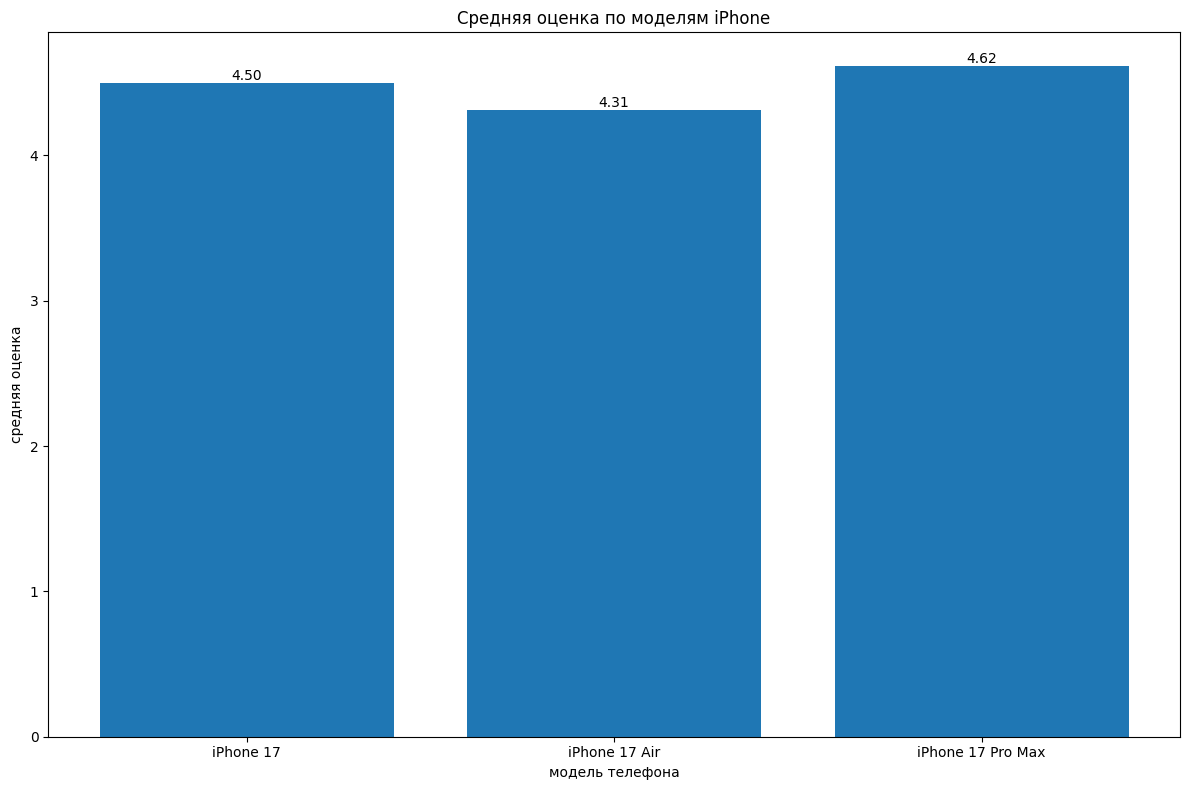

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df['rating'] = pd.to_numeric(df['rating'])

group = df.groupby('model')['rating'].mean()



plt.figure(figsize=(12, 8))

bars = plt.bar(group.index, group)
plt.bar_label(bars, labels=[f"{v:.2f}" for v in group])

plt.xlabel('модель телефона')
plt.ylabel('средняя оценка')
plt.title('Средняя оценка по моделям iPhone')
plt.tight_layout()
plt.show()


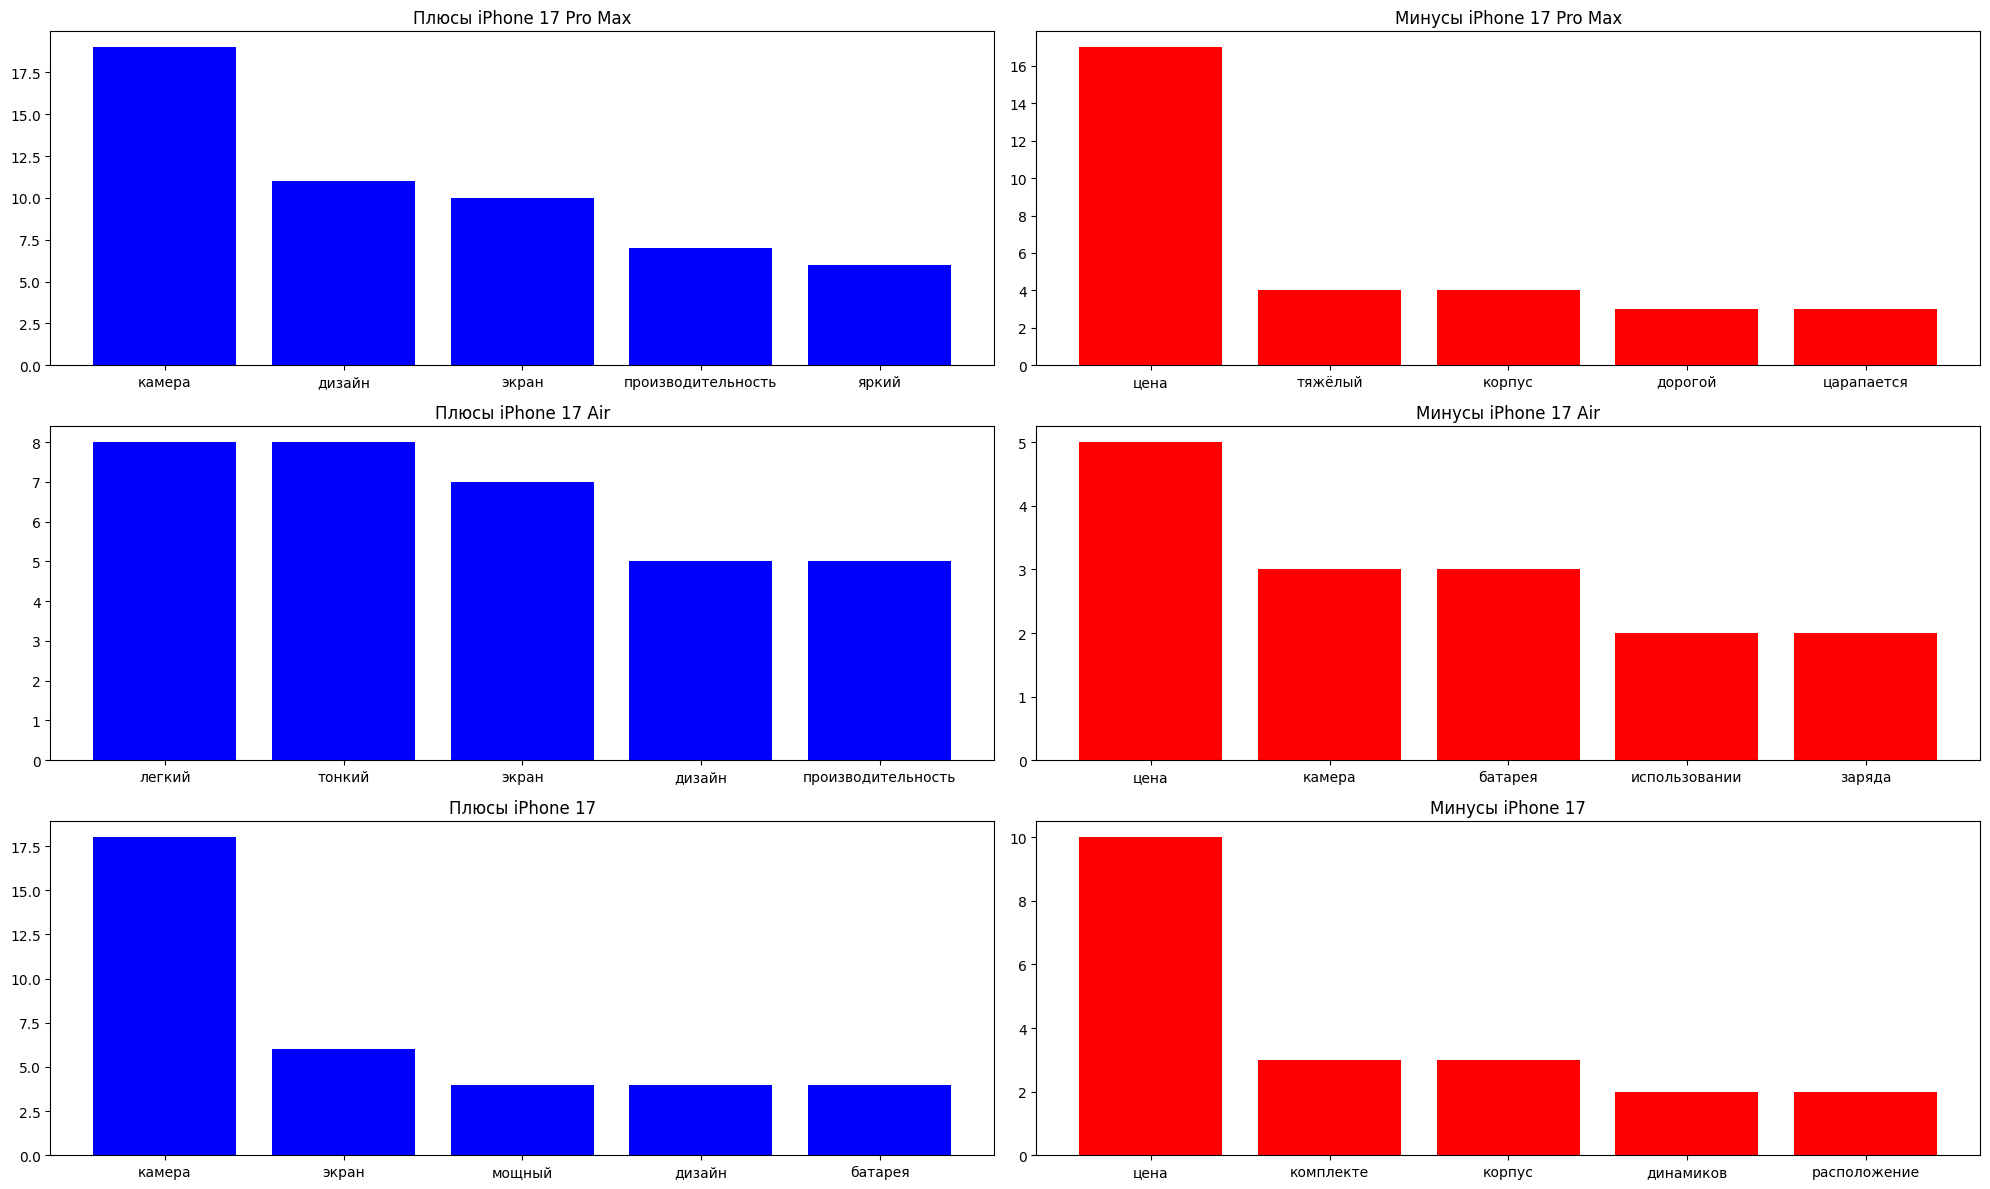

In [ ]:
import matplotlib.pyplot as plt

# Создаем фигуру с 3 строками и 2 столбцами (для трех моделей)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 12))

for i, model_name in enumerate(URLS.keys()):
    plus = models_plus[model_name]
    minus = models_minus[model_name]

    # Горизонтальные столбцы для плюсов
    axes[i, 0].bar(plus.index, plus.values, color='blue')
    axes[i, 0].set_title(f'Плюсы {model_name}')

    # Горизонтальные столбцы для минусов
    axes[i, 1].bar(minus.index, minus.values, color='red')
    axes[i, 1].set_title(f'Минусы {model_name}')

plt.tight_layout()
plt.show()


### Шаг 5: Выводы по анализу


На основе построенных визуализаций можно сделать следующие выводы:

1. iphone 17 pro max имеет самую высокую среднюю оценку 4.62, меньше всего понравился iphone 17 air


2.  Камера и экран являются ключевым преимуществом, на которые пользователи обращают внимание.

Дизайн и производительность также важны для всех моделей.

Для модели air важна легкость и тонкость.

3.  Цена — ключевая проблема для всех моделей.

Большой вес и неудобный корпус — для модели Pro Max,

для Air — низкое качество камера и размера батареи.

в 17 модели пользователи отмечают, по мимо цены, ухудшение в комплекте поставляемом с телефоном (отсутствие блока для зарядки) и неудобный корпус